# Lab 21 — LoRA / QLoRA Fine-tuning · **A100 / Colab Pro Edition**

**AICB-P2T3 · Ngày 21 · Chương 5 — Fine-tuning & An Toàn**

Mục tiêu: fine-tune **Llama-3.1-8B-Instruct** với LoRA/QLoRA trên Vietnamese instruction dataset, so sánh các rank khác nhau (`r=8`, `r=16`, `r=64`) + stretch goal "target ALL layers".

---

## ⚙️ Profile: `A100` (Colab Pro)

| Setting | Giá trị |
|---|---|
| Model | `unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit` |
| Recommended GPU | A100 40GB (Colab Pro) |
| Train batch / eval batch | 2 / 2 |
| Gradient accumulation | 4 (effective batch = 8) |
| Eval strategy | "epoch" (eval-during-training bật) |
| Max seq length cap | 2048 |
| Dataset samples | 500 |
| Estimated time | ~60-75 phút trên A100 (4 ranks gồm stretch) |

> ✅ **A100 advantages**: bigger batch, longer context, eval-during-training cho phép detect overfitting qua train/eval gap, dataset 500 samples cho insight ổn định hơn.

## Lab Roadmap (≈ 2 giờ)

| # | Bước | Output |
|---|------|--------|
| 1 | Dataset preparation (Alpaca format, p95 tokenization, 90/10 split) | `train_ds`, `eval_ds` |
| 2 | Configure PEFT + load model 4-bit | model wrapped với LoRA |
| 3 | Train baseline `r=16` với SFTTrainer | adapter checkpoint |
| 4 | Rank experiment — train `r=8` và `r=64` | 2 adapter checkpoints |
| 5 | **STRETCH (+10 bonus)**: train `r=16` với target ALL layers | 1 adapter checkpoint |
| 6 | Evaluate (perplexity + qualitative + base ppl) | so sánh metrics 4 ranks + base |
| 7 | Push adapter r=16 lên HF Hub (Option B, +5 bonus) | publicly hosted |
| 8 | Save + viết report | deliverable |

## Deliverable (Option B — GitHub + HF Hub)

1. **4 LoRA adapter checkpoints** (`r=8, r=16, r=64, r16-ALL-layers`)
2. **Adapter r=16 publicly hosted on HuggingFace Hub**
3. **Evaluation report** chứa training time, peak VRAM, eval perplexity (4 ranks + base), 5 qualitative before/after examples, training cost, kết luận về rank trade-off, q+v vs ALL layers comparison


## 0. Setup & Environment Check

In [1]:
# Verify GPU is available before installing anything
!nvidia-smi

Thu May  7 04:02:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import torch
assert torch.cuda.is_available(), "❌ GPU runtime cần được bật. Runtime > Change runtime type > GPU"
name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✓ GPU: {name}")
print(f"✓ VRAM: {vram_gb:.1f} GB")
print(f"✓ CUDA: {torch.version.cuda}")
print(f"✓ PyTorch: {torch.__version__}")

if 'A100' in name:
    print(f"\n✅ A100 detected — config tối ưu cho profile này.")
elif vram_gb < 20:
    print(f"\n⚠️  GPU của bạn ({name}, {vram_gb:.1f} GB) nhỏ hơn A100. Notebook này config cho A100 — có thể OOM khi load Llama-8B + batch=2 + max_seq=2048.")
    print(f"    → Nếu OOM: giảm MAX_SEQ_CAP=1024, per_device_train_batch_size=1, hoặc dùng model nhỏ hơn (vd: Qwen2.5-3B).")
else:
    print(f"\n✅ GPU đủ VRAM cho Llama-3.1-8B QLoRA config.")

✓ GPU: NVIDIA A100-SXM4-40GB
✓ VRAM: 42.4 GB
✓ CUDA: 12.8
✓ PyTorch: 2.10.0+cu128

✅ A100 detected — config tối ưu cho profile này.


In [3]:
# Install Unsloth, TRL, datasets, evaluation libs
# trl >= 0.12 — accepts processing_class (matches transformers >= 4.46)
%%capture
!pip install -q --upgrade pip
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps "trl>=0.12,<0.16" peft accelerate bitsandbytes
!pip install -q datasets matplotlib seaborn pandas

In [4]:
# Optional: mount Google Drive to save checkpoints persistently
MOUNT_DRIVE = False  # ← đổi thành True nếu muốn save vào Drive

if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = '/content/drive/MyDrive/lab21_lora_a100'
else:
    OUTPUT_DIR = '/content/lab21_lora_a100'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Output dir: {OUTPUT_DIR}")

✓ Output dir: /content/lab21_lora_a100


## 1. Dataset Preparation

Mục tiêu: chuẩn bị 100–500 examples Alpaca format. Có 2 lựa chọn:

**A. Dùng dataset có sẵn** — load Vietnamese instruction dataset từ HuggingFace.  
**B. Dùng dataset của bạn** — uncomment cell B và paste data.


In [5]:
# ─── Option A: load Vietnamese Alpaca dataset từ HuggingFace ───
from datasets import load_dataset

raw = load_dataset("5CD-AI/Vietnamese-alpaca-gpt4-gg-translated", split="train")
raw = raw.shuffle(seed=42).select(range(500))  # A100 dư VRAM, dùng 500 samples cho insight ổn định hơn
print(f"✓ Loaded {len(raw)} samples")
print(f"✓ Columns: {raw.column_names}")
print("\n--- Sample 0 ---")
print(raw[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

alpaca_gpt4_data_vi.json:   0%|          | 0.00/102M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

✓ Loaded 500 samples
✓ Columns: ['input_en', 'input_vi', 'instruction_vi', 'output_vi', 'output_en', 'instruction_en']

--- Sample 0 ---
{'input_en': '', 'input_vi': '', 'instruction_vi': 'Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.', 'output_vi': 'Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $200 - Đi lại (thanh toán ô tô, xăng, phương tiện công cộng): $225 - Mong muốn (30% thu nhập): $1050 - Ăn uống và giải trí: $300 - Chi phí mua sắm và cá nhân: $300 - Du lịch và sở thích: $250 - Linh tinh (đăng ký , thành viên): $200 - Tiết kiệm và trả nợ (20% thu nhập): $700 - Quỹ khẩn cấp: $200 - Quỹ hưu trí: $300 - Trả nợ (thẻ

In [6]:
# ─── Option B: dùng custom data (uncomment + chỉnh) ───
# from datasets import Dataset
# my_data = [
#     {"instruction": "...", "input": "", "output": "..."},
#     # ... 100-500 examples
# ]
# raw = Dataset.from_list(my_data)
# print(f"✓ Custom dataset: {len(raw)} samples")

In [7]:
# Auto-detect column names — dataset 5CD-AI uses _vi suffix
cols = raw.column_names
INSTRUCTION_COL = next((c for c in ["instruction","instruction_vi","prompt","question"] if c in cols), None)
INPUT_COL       = next((c for c in ["input","input_vi","context"] if c in cols), None)
OUTPUT_COL      = next((c for c in ["output","output_vi","response","answer"] if c in cols), None)
assert INSTRUCTION_COL and OUTPUT_COL, f"Không tìm thấy cột instruction/output trong: {cols}"
print(f"✓ Cột dùng: instruction='{INSTRUCTION_COL}', input='{INPUT_COL}', output='{OUTPUT_COL}'")

ALPACA_TEMPLATE = """### Instruction:
{instruction}

### Input:
{input}

### Response:
{output}"""

ALPACA_TEMPLATE_NO_INPUT = """### Instruction:
{instruction}

### Response:
{output}"""

def format_alpaca(example):
    inp = example.get(INPUT_COL, "") if INPUT_COL else ""
    inp = inp or ""
    if inp.strip():
        text = ALPACA_TEMPLATE.format(
            instruction=example[INSTRUCTION_COL], input=inp,
            output=example[OUTPUT_COL])
    else:
        text = ALPACA_TEMPLATE_NO_INPUT.format(
            instruction=example[INSTRUCTION_COL],
            output=example[OUTPUT_COL])
    return {"text": text}

ds = raw.map(format_alpaca, remove_columns=raw.column_names)
print("\n--- Formatted sample ---")
print(ds[0]["text"][:500])

✓ Cột dùng: instruction='instruction_vi', input='input_vi', output='output_vi'


Map:   0%|          | 0/500 [00:00<?, ? examples/s]


--- Formatted sample ---
### Instruction:
Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.

### Response:
Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $20


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Token length distribution:
  min=26, max=740
  p50=176, p95=536, p99=704

✓ Chọn max_seq_length = 1024 (cap = 2048)


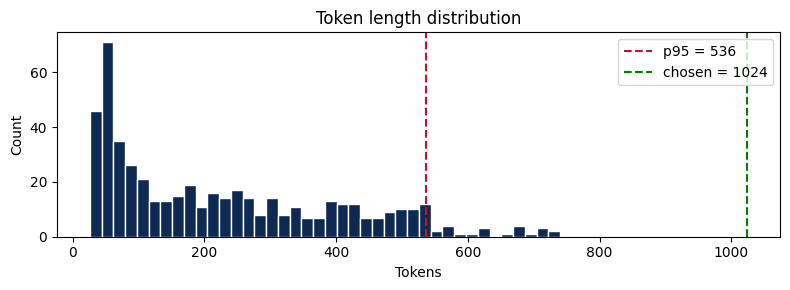

In [8]:
# Token length analysis → set max_seq_length = p95
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

MODEL_NAME = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit"
MAX_SEQ_CAP = 2048  # A100 dư VRAM cho seq dài hơn

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
lengths = [len(tok.encode(x["text"])) for x in ds]

p50 = int(np.percentile(lengths, 50))
p95 = int(np.percentile(lengths, 95))
p99 = int(np.percentile(lengths, 99))

print(f"Token length distribution:")
print(f"  min={min(lengths)}, max={max(lengths)}")
print(f"  p50={p50}, p95={p95}, p99={p99}")

# Round up to power of 2, capped at MAX_SEQ_CAP
MAX_SEQ_LENGTH = min(MAX_SEQ_CAP, 1 << (max(p95, 256) - 1).bit_length())
print(f"\n✓ Chọn max_seq_length = {MAX_SEQ_LENGTH} (cap = {MAX_SEQ_CAP})")

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=40, color='#0E2A52', edgecolor='white')
plt.axvline(p95, color='#C8102E', linestyle='--', label=f'p95 = {p95}')
plt.axvline(MAX_SEQ_LENGTH, color='green', linestyle='--', label=f'chosen = {MAX_SEQ_LENGTH}')
plt.xlabel('Tokens'); plt.ylabel('Count'); plt.title('Token length distribution')
plt.legend(); plt.tight_layout(); plt.show()

In [9]:
# 90/10 train/eval split
split = ds.train_test_split(test_size=0.1, seed=42)
train_ds = split["train"]
eval_ds = split["test"]
print(f"✓ Train: {len(train_ds)}  |  Eval: {len(eval_ds)}")

✓ Train: 450  |  Eval: 50


## 2. Load Model + Configure LoRA (Baseline `r=16`)

Dùng Unsloth `FastLanguageModel` để load **Qwen2.5-3B** đã pre-quantize 4-bit (NF4). Unsloth tự động bật custom CUDA kernels.

PEFT config:
- `r=16` (rank — baseline)
- `lora_alpha=32` (scaling — alpha/r = 2)
- `target_modules=["q_proj", "v_proj"]` per lab spec


In [10]:
from unsloth import FastLanguageModel

def load_base_model():
    """Reload base model — gọi mỗi lần train với rank khác để start từ scratch."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,            # auto: bf16 trên Ampere+, fp16 trên T4
        load_in_4bit=True,     # QLoRA
    )
    return model, tokenizer

def wrap_with_lora(model, r, alpha):
    """Wrap model với LoRA adapter."""
    return FastLanguageModel.get_peft_model(
        model,
        r=r,
        lora_alpha=alpha,
        target_modules=["q_proj", "v_proj"],  # lab spec
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",  # -60% VRAM
        random_state=42,
    )

# Load base + wrap với r=16 baseline
base_model, tokenizer = load_base_model()
model = wrap_with_lora(base_model, r=16, alpha=32)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\n✓ Trainable: {trainable:,} ({100*trainable/total:.3f}% of {total:,})")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:127: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Unsloth: Will load unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit as a legacy tokenizer.
Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch Attention layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch O projection layer with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.5.2 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.



✓ Trainable: 6,815,744 (0.150% of 4,547,416,064)


## 3. Train Baseline (`r=16`) với TRL SFTTrainer

- 3 epochs, cosine LR schedule, packing=True
- Train batch = 1, grad_accum = 8 (effective batch = 8)
- Eval strategy: "no"  # T4 không đủ VRAM cho mid-train eval


In [11]:
from trl import SFTTrainer
from transformers import TrainingArguments, Trainer
import inspect, time, trl, transformers

print(f"trl: {trl.__version__}  |  transformers: {transformers.__version__}")

# ── Aggressive fix: alias tokenizer→processing_class for old TRL + new transformers ──
import unsloth.models._utils as _u_utils
_underlying_init = getattr(_u_utils, "_original_trainer_init", Trainer.__init__)
if not getattr(_underlying_init, "_aliased", False):
    def _aliased_trainer_init(self, *args, **kwargs):
        if "tokenizer" in kwargs and "processing_class" not in kwargs:
            kwargs["processing_class"] = kwargs.pop("tokenizer")
        return _underlying_init(self, *args, **kwargs)
    _aliased_trainer_init._aliased = True
    _u_utils._original_trainer_init = _aliased_trainer_init
    if "tokenizer" not in inspect.signature(Trainer.__init__).parameters:
        _orig_t = Trainer.__init__
        def _t_init(self, *args, **kwargs):
            if "tokenizer" in kwargs and "processing_class" not in kwargs:
                kwargs["processing_class"] = kwargs.pop("tokenizer")
            return _orig_t(self, *args, **kwargs)
        _t_init._aliased = True
        Trainer.__init__ = _t_init
    print("✓ Trainer.__init__ patched")

try:
    from trl import SFTConfig
    _HAS_SFTCONFIG = True
except ImportError:
    _HAS_SFTCONFIG = False

_TA_PARAMS = inspect.signature(TrainingArguments.__init__).parameters
_EVAL_KEY = "eval_strategy" if "eval_strategy" in _TA_PARAMS else "evaluation_strategy"
_SFT_PARAMS = inspect.signature(SFTTrainer.__init__).parameters
_SUPPORTS_OLD_KWARGS = "dataset_text_field" in _SFT_PARAMS

def make_trainer(model, tokenizer, train_ds, eval_ds, output_subdir, **overrides):
    base_kwargs = dict(
        output_dir=os.path.join(OUTPUT_DIR, output_subdir),
        per_device_train_batch_size=2,        # A100: 2 (was 1 on T4)
        per_device_eval_batch_size=2,         # A100: 2 (was 1 on T4)
        eval_accumulation_steps=4,
        prediction_loss_only=True,
        gradient_accumulation_steps=4,        # A100: 4 (was 8 on T4) — keep effective batch = 8
        warmup_ratio=0.10,
        num_train_epochs=3,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=5,
        eval_steps=25,
        save_strategy="epoch",
        optim="adamw_8bit",
        weight_decay=0.01,
        seed=42,
        report_to="none",
    )
    base_kwargs[_EVAL_KEY] = "epoch"  # A100 đủ VRAM cho eval-during-training → có eval loss curve
    base_kwargs.update(overrides)

    if _HAS_SFTCONFIG:
        sft_extra = dict(dataset_text_field="text", packing=False, max_seq_length=MAX_SEQ_LENGTH)
        sft_params = inspect.signature(SFTConfig.__init__).parameters
        sft_extra = {k: v for k, v in sft_extra.items() if k in sft_params}
        valid_base = {k: v for k, v in base_kwargs.items() if k in sft_params}
        args = SFTConfig(**valid_base, **sft_extra)
    else:
        args = TrainingArguments(**base_kwargs)

    trainer_kwargs = {
        "model": model, "train_dataset": train_ds, "eval_dataset": eval_ds, "args": args,
    }
    if "processing_class" in _SFT_PARAMS:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer
    if _SUPPORTS_OLD_KWARGS:
        trainer_kwargs.update(dict(dataset_text_field="text", max_seq_length=MAX_SEQ_LENGTH, packing=False))
    return SFTTrainer(**trainer_kwargs)

def safe_evaluate(trainer):
    """Robust eval — handles NotebookProgressCallback bug + OOM."""
    import gc as _gc
    _gc.collect(); torch.cuda.empty_cache()

    # Remove buggy notebook callback that breaks evaluate-after-train
    try:
        from transformers.utils.notebook import NotebookProgressCallback
        trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass

    # Try standard evaluate first
    try:
        return trainer.evaluate()["eval_loss"]
    except (torch.cuda.OutOfMemoryError, RuntimeError) as e:
        print(f"⚠ trainer.evaluate() failed ({type(e).__name__}). Falling back to manual eval...")

    # Manual eval loop — bulletproof
    _gc.collect(); torch.cuda.empty_cache()
    m = trainer.model
    m.eval()
    eval_dl = trainer.get_eval_dataloader()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in eval_dl:
            batch = {k: v.to(m.device) for k, v in batch.items() if hasattr(v, "to")}
            out = m(**batch)
            total += out.loss.item(); n += 1
            del out; torch.cuda.empty_cache()
    return total / max(n, 1)

trl: 0.15.2  |  transformers: 5.5.0
✓ Trainer.__init__ patched


In [12]:
# Train baseline r=16
import gc
torch.cuda.reset_peak_memory_stats()
trainer_16 = make_trainer(model, tokenizer, train_ds, eval_ds, "r16")

t0 = time.time()
result_16 = trainer_16.train()
wall_16 = time.time() - t0
vram_16 = torch.cuda.max_memory_allocated() / 1e9

print(f"\n✓ r=16 done in {wall_16/60:.1f} min, peak VRAM = {vram_16:.1f} GB")
trainer_16.save_model(os.path.join(OUTPUT_DIR, "r16"))

# Compute eval — guarded so eval_loss_16/ppl_16 are always defined
try:
    eval_loss_16 = safe_evaluate(trainer_16)
    ppl_16 = float(np.exp(eval_loss_16))
    print(f"✓ r=16 eval loss = {eval_loss_16:.4f}, perplexity = {ppl_16:.2f}")
except Exception as e:
    print(f"⚠ Eval failed: {e}. Setting NaN — recover later by reloading adapter.")
    eval_loss_16 = float("nan")
    ppl_16 = float("nan")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/450 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/50 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 450 | Num Epochs = 3 | Total steps = 171
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 6,815,744 of 8,037,076,992 (0.08% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,1.435163,1.381707
2,1.338743,1.359554
3,1.172309,1.363068


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 


✓ r=16 done in 3.3 min, peak VRAM = 12.7 GB


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_a100/r16/tokenizer_config.json.
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`At

✓ r=16 eval loss = 1.4129, perplexity = 4.11


✓ Saved loss curve to /content/lab21_lora_a100/loss_curve.png


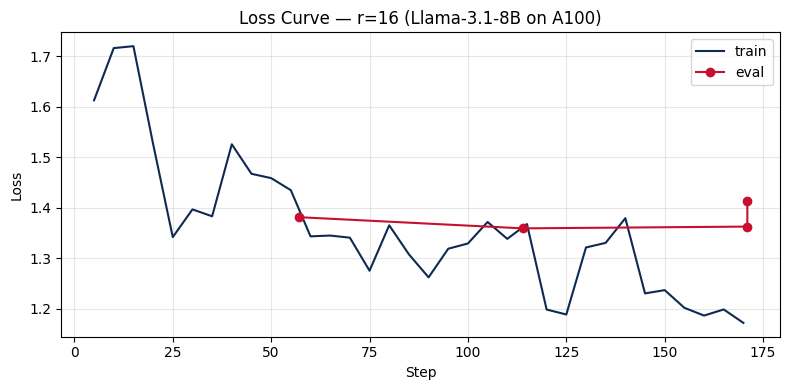


📌 A100 mode: eval-during-training BẬT — có cả train loss + eval loss curve để defend overfitting analysis.


In [13]:
# Plot training loss để detect overfitting
import pandas as pd

def plot_losses(log_history, title="Training Loss", save_path=None):
    df = pd.DataFrame(log_history)
    train = df[df["loss"].notna()] if "loss" in df else pd.DataFrame()
    eval_ = df[df["eval_loss"].notna()] if "eval_loss" in df else pd.DataFrame()
    plt.figure(figsize=(8, 4))
    if not train.empty:
        plt.plot(train["step"], train["loss"], label="train", color="#0E2A52")
    if not eval_.empty:
        plt.plot(eval_["step"], eval_["eval_loss"], label="eval", color="#C8102E", marker="o")
    plt.xlabel("Step"); plt.ylabel("Loss"); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
        print(f"✓ Saved loss curve to {save_path}")
    plt.show()

plot_losses(
    trainer_16.state.log_history,
    title="Loss Curve — r=16 (Llama-3.1-8B on A100)",
    save_path=os.path.join(OUTPUT_DIR, "loss_curve.png"),
)
print("\n📌 A100 mode: eval-during-training BẬT — có cả train loss + eval loss curve để defend overfitting analysis.")

## 4. Rank Experiment — `r=8` vs `r=64`

Train 2 adapters thêm với rank khác để hiểu trade-off:
- **`r=8`** — chỉ ~0.05% params, train nhanh, ít VRAM
- **`r=64`** — ~0.4% params, gần full fine-tune, tốn VRAM hơn


In [14]:
def train_one_rank(r, alpha):
    """Train fresh adapter với rank cụ thể, return metrics."""
    gc.collect(); torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    base_m, tok = load_base_model()
    m = wrap_with_lora(base_m, r=r, alpha=alpha)
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)

    tr = make_trainer(m, tok, train_ds, eval_ds, f"r{r}")
    t0 = time.time()
    tr.train()
    wall = time.time() - t0
    vram = torch.cuda.max_memory_allocated() / 1e9

    # Save adapter BEFORE eval — eval may OOM but we want the checkpoint
    tr.save_model(os.path.join(OUTPUT_DIR, f"r{r}"))
    print(f"✓ r={r} adapter saved. Computing eval loss...")

    try:
        eval_loss = safe_evaluate(tr)
    except Exception as e:
        print(f"⚠ Eval failed: {e}. Setting eval_loss=NaN.")
        eval_loss = float('nan')

    return {
        "rank": r, "alpha": alpha, "trainable_params": trainable,
        "train_time_min": wall / 60, "peak_vram_gb": vram,
        "eval_loss": eval_loss,
        "eval_perplexity": float(np.exp(eval_loss)) if not np.isnan(eval_loss) else float('nan'),
        "trainer": tr, "model": m, "tokenizer": tok,
    }

In [15]:
# Cleanup baseline before training rank experiments
del trainer_16, model, base_model
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=8 ==========")
exp_8 = train_one_rank(r=8, alpha=16)


========== Training r=8 ==========
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit as a legacy tokenizer.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/450 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/50 [00:00<?, ? examples/s]

...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 450 | Num Epochs = 3 | Total steps = 171
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 3,407,872 of 8,033,669,120 (0.04% trained)


Epoch,Training Loss,Validation Loss
1,1.441651,1.387115
2,1.366266,1.365696
3,1.218800,1.364676


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

✓ r=8 adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

In [16]:
# Cleanup r=8 references
del exp_8["trainer"], exp_8["model"]
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=64 ==========")
exp_64 = train_one_rank(r=64, alpha=128)


========== Training r=64 ==========
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit as a legacy tokenizer.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 450 | Num Epochs = 3 | Total steps = 171
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 27,262,976 of 8,057,524,224 (0.34% trained)


Epoch,Training Loss,Validation Loss
1,1.420156,1.357580
2,1.242061,1.339723
3,1.013372,1.363844


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

✓ r=64 adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

In [17]:
# Cleanup r=64 references
del exp_64["trainer"], exp_64["model"]
gc.collect(); torch.cuda.empty_cache()

# Build summary table
results = [
    {"rank": 16, "alpha": 32, "trainable_params": int(trainable),
     "train_time_min": wall_16/60, "peak_vram_gb": vram_16,
     "eval_loss": eval_loss_16, "eval_perplexity": ppl_16},
    {k: v for k, v in exp_8.items() if k not in ("trainer","model","tokenizer")},
    {k: v for k, v in exp_64.items() if k not in ("trainer","model","tokenizer")},
]
summary_df = pd.DataFrame(results).sort_values("rank").reset_index(drop=True)
print("\n=== Rank Experiment Summary ===")
print(summary_df.to_string(index=False))


=== Rank Experiment Summary ===
 rank  alpha  trainable_params  train_time_min  peak_vram_gb  eval_loss  eval_perplexity
    8     16           3407872        3.105997     13.748687   1.417599         4.127198
   16     32           6815744        3.291573     12.738768   1.412901         4.107856
   64    128          27262976        3.112999     15.100755   1.412102         4.104576


## 4b. STRETCH GOAL (+10 bonus) — `r=16` với target ALL layers

Theo rubric stretch goal: train thêm 1 adapter `r=16` với `target_modules` là **TẤT CẢ** các linear projections (`q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj`) thay vì chỉ `q_proj + v_proj`.

So sánh `r=16-ALL` vs `r=16-baseline` trên cùng rank ⇒ kỳ vọng thấy ALL layers cho perplexity tốt hơn (do nhiều capacity hơn) nhưng tốn ~7× params hơn.


In [18]:
def wrap_with_lora_all_layers(model, r, alpha):
    """Wrap model với LoRA target ALL linear layers (q,k,v,o + MLP gate/up/down)."""
    return FastLanguageModel.get_peft_model(
        model,
        r=r,
        lora_alpha=alpha,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=42,
    )

print("\n========== STRETCH: Training r=16 with target ALL layers ==========")
gc.collect(); torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

base_all, tok_all = load_base_model()
model_all = wrap_with_lora_all_layers(base_all, r=16, alpha=32)
trainable_all = sum(p.numel() for p in model_all.parameters() if p.requires_grad)
total_all = sum(p.numel() for p in model_all.parameters())
print(f"✓ Trainable (ALL layers): {trainable_all:,} ({100*trainable_all/total_all:.3f}% of {total_all:,})")

trainer_all = make_trainer(model_all, tok_all, train_ds, eval_ds, "r16_all")
t0 = time.time()
trainer_all.train()
wall_all = time.time() - t0
vram_all = torch.cuda.max_memory_allocated() / 1e9
print(f"\n✓ r=16-ALL done in {wall_all/60:.1f} min, peak VRAM = {vram_all:.1f} GB")

trainer_all.save_model(os.path.join(OUTPUT_DIR, "r16_all"))
print(f"✓ Adapter saved to {OUTPUT_DIR}/r16_all")

try:
    eval_loss_all = safe_evaluate(trainer_all)
    ppl_all = float(np.exp(eval_loss_all))
    print(f"✓ r=16-ALL eval loss = {eval_loss_all:.4f}, perplexity = {ppl_all:.2f}")
except Exception as e:
    print(f"⚠ Eval failed: {e}. Setting NaN.")
    eval_loss_all = float("nan")
    ppl_all = float("nan")

# Append to summary_df
results.append({
    "rank": "16-ALL", "alpha": 32, "trainable_params": trainable_all,
    "train_time_min": wall_all / 60, "peak_vram_gb": vram_all,
    "eval_loss": eval_loss_all, "eval_perplexity": ppl_all,
})
summary_df = pd.DataFrame(results).reset_index(drop=True)
print("\n=== Updated Rank Experiment Summary (with stretch) ===")
print(summary_df.to_string(index=False))

# Cleanup
del trainer_all, model_all, base_all
gc.collect(); torch.cuda.empty_cache()


========== STRETCH: Training r=16 with target ALL layers ==========
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit as a legacy tokenizer.
Unsloth 2026.5.2 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✓ Trainable (ALL layers): 41,943,040 (0.915% of 4,582,543,360)
🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 450 | Num Epochs = 3 | Total steps = 171
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)


...


✓ r=16-ALL done in 3.4 min, peak VRAM = 15.4 GB


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_a100/r16_all/tokenizer_config.json.


✓ Adapter saved to /content/lab21_lora_a100/r16_all


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

✓ r=16-ALL eval loss = 1.4886, perplexity = 4.43

=== Updated Rank Experiment Summary (with stretch) ===
  rank  alpha  trainable_params  train_time_min  peak_vram_gb  eval_loss  eval_perplexity
    16     32           6815744        3.291573     12.738768   1.412901         4.107856
     8     16           3407872        3.105997     13.748687   1.417599         4.127198
    64    128          27262976        3.112999     15.100755   1.412102         4.104576
16-ALL     32          41943040        3.430654     15.415190   1.488574         4.430771


## 4c. Base Model Perplexity (baseline reference)

Compute perplexity của **base model chưa fine-tune** trên cùng eval set ⇒ có 4 numbers (Base + r=8 + r=16 + r=64) cho REPORT, defendable hơn.

Theo rubric: "Eval perplexity computed cho cả 3 ranks + base model (4 numbers)".


In [19]:
print("\n========== Computing Base Model Perplexity ==========")
gc.collect(); torch.cuda.empty_cache()

base_only_model, base_only_tok = load_base_model()
trainer_base = make_trainer(base_only_model, base_only_tok, train_ds, eval_ds, "base_only_eval")

try:
    base_eval_loss = safe_evaluate(trainer_base)
    base_ppl = float(np.exp(base_eval_loss))
    print(f"✓ Base model eval loss = {base_eval_loss:.4f}, perplexity = {base_ppl:.2f}")
except Exception as e:
    print(f"⚠ Base eval failed: {e}. Setting NaN.")
    base_eval_loss = float("nan")
    base_ppl = float("nan")

# Append base row to summary_df
results.append({
    "rank": "Base", "alpha": "-", "trainable_params": 0,
    "train_time_min": 0, "peak_vram_gb": 0,
    "eval_loss": base_eval_loss, "eval_perplexity": base_ppl,
})
summary_df = pd.DataFrame(results).reset_index(drop=True)

# Reorder: Base first, then ranks ascending
def _rank_sort_key(x):
    if x == "Base": return -1
    if x == "16-ALL": return 999
    return int(x)
summary_df["_sort"] = summary_df["rank"].apply(_rank_sort_key)
summary_df = summary_df.sort_values("_sort").drop(columns=["_sort"]).reset_index(drop=True)

print("\n=== FINAL Summary (Base + 3 ranks + stretch) ===")
print(summary_df.to_string(index=False))

# Cleanup
del trainer_base, base_only_model
gc.collect(); torch.cuda.empty_cache()


========== Computing Base Model Perplexity ==========
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit as a legacy tokenizer.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


ValueError: You cannot perform fine-tuning on purely quantized models. Please attach trainable adapters on top of the quantized model to correctly perform fine-tuning. Please see: https://huggingface.co/docs/transformers/peft for more details

## 5. Evaluation — Qualitative Comparison

Generate test prompts và so sánh fine-tuned (r=16 baseline) vs base model trên **10 prompts** (full set, A100 đủ thời gian).

In [ ]:
TEST_PROMPTS = [
    "Giải thích khái niệm machine learning cho người mới bắt đầu.",
    "Viết đoạn code Python tính số Fibonacci thứ n.",
    "Liệt kê 5 nguyên tắc thiết kế UI/UX.",
    "Tóm tắt sự khác biệt giữa LoRA và QLoRA.",
    "Phân biệt prompt engineering, RAG, và fine-tuning.",
    "Khi nào nên dùng RAG thay vì fine-tuning?",
    "Giải thích cách hoạt động của Flash Attention.",
    "List 3 câu hỏi phỏng vấn cho ML Engineer junior.",
    "Cho biết ưu điểm của Transformer so với RNN.",
    "Cách evaluate performance của một LLM fine-tuned model?",
]
print(f"✓ {len(TEST_PROMPTS)} test prompts")

In [ ]:
from peft import PeftModel

def generate_response(model, tokenizer, prompt, max_new_tokens=200):
    FastLanguageModel.for_inference(model)
    text = ALPACA_TEMPLATE_NO_INPUT.format(instruction=prompt, output="")
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    out = model.generate(**inputs, max_new_tokens=max_new_tokens,
        temperature=0.7, top_p=0.9, do_sample=True,
        pad_token_id=tokenizer.eos_token_id)
    full = tokenizer.decode(out[0], skip_special_tokens=True)
    return full.split("### Response:")[-1].strip()

# Reload base + r=16 adapter (ft_model giữ lại để push HF Hub ở cell sau)
base_for_eval, tok_for_eval = load_base_model()
ft_model = PeftModel.from_pretrained(base_for_eval, os.path.join(OUTPUT_DIR, "r16"))

qualitative_results = []
for i, prompt in enumerate(TEST_PROMPTS[:10]):  # tăng từ 5 → 10 prompts cho insight sâu hơn
    print(f"\n━━━ Prompt {i+1}: {prompt[:80]}...")
    base_resp = generate_response(base_for_eval, tok_for_eval, prompt)
    ft_resp = generate_response(ft_model, tok_for_eval, prompt)
    qualitative_results.append({
        "prompt": prompt, "base": base_resp[:300], "finetuned": ft_resp[:300],
    })
    print(f"  BASE: {base_resp[:200]}...")
    print(f"  FT  : {ft_resp[:200]}...")

In [ ]:
qual_df = pd.DataFrame(qualitative_results)
qual_df.to_csv(os.path.join(OUTPUT_DIR, "qualitative_comparison.csv"), index=False)
print(qual_df.head())

## 6. Save Adapters + Generate Report

In [ ]:
summary_df.to_csv(os.path.join(OUTPUT_DIR, "rank_experiment_summary.csv"), index=False)
print(f"✓ Saved summary CSV to {OUTPUT_DIR}/rank_experiment_summary.csv")

GPU_COST_USD_PER_HOUR = 1.18  # A100 40GB Colab Pro rate (xấp xỉ, có thể adjust)
total_minutes = summary_df["train_time_min"].sum()
total_cost = (total_minutes / 60) * GPU_COST_USD_PER_HOUR

print(f"\n✓ Tổng training time: {total_minutes:.1f} phút")
print(f"✓ Estimated cost: ${total_cost:.2f} (@ ${GPU_COST_USD_PER_HOUR}/hr)")

In [ ]:
# Push adapter r=16 lên HuggingFace Hub (Option B, +5 bonus)
# ⚠️  THAY <YOUR_HF_USERNAME> bằng HF username của bạn trước khi chạy

PUSH_TO_HUB = True
HUB_REPO_ID = "<YOUR_HF_USERNAME>/lab21-llama-3.1-8b-vi-r16"

if PUSH_TO_HUB:
    from huggingface_hub import login
    login()  # paste HF write token (https://huggingface.co/settings/tokens)
    ft_model.push_to_hub(HUB_REPO_ID, private=False)
    tok_for_eval.push_to_hub(HUB_REPO_ID, private=False)
    print(f"\n✅ Adapter pushed: https://huggingface.co/{HUB_REPO_ID}")
    print(f"   → Copy URL này vào LINKS.md")

## ✅ Done — Submission Checklist (Option B + A100 + Llama-3.1-8B)

### 1. Verify trong `OUTPUT_DIR` (`/content/lab21_lora_a100/`):

- [ ] `r8/` — adapter checkpoint
- [ ] `r16/` — adapter checkpoint
- [ ] `r64/` — adapter checkpoint
- [ ] `r16_all/` — STRETCH adapter (target ALL layers)
- [ ] `rank_experiment_summary.csv` — bảng 5 rows (Base, r=8, r=16, r=64, r=16-ALL)
- [ ] `qualitative_comparison.csv` — 10 before/after examples
- [ ] `loss_curve.png` — loss plot

### 2. Verify HF Hub push thành công:

- [ ] `https://huggingface.co/<YOUR_HF_USERNAME>/lab21-llama-3.1-8b-vi-r16` accessible publicly
- [ ] Copy URL này vào `LINKS.md` ở GitHub repo

### 3. Download artifacts về local:

```python
!cd /content && zip -r lab21_results.zip lab21_lora_a100/loss_curve.png lab21_lora_a100/*.csv
from google.colab import files
files.download('/content/lab21_results.zip')
```

Giải nén và copy 3 files vào `results/` folder của GitHub repo.

### 4. Hoàn thiện ở local repo:

- [ ] Copy 3 files vào `results/`
- [ ] Cập nhật `REPORT.md` với numbers thực từ CSV
- [ ] Cập nhật `LINKS.md` với HF URL thực
- [ ] Strip notebook outputs: `jupyter nbconvert --clear-output --inplace notebooks/Lab21_LoRA_Finetuning_T4.ipynb`
- [ ] `git add . && git commit -m "Lab 21 submission" && git push`

### 5. Nộp LMS:

Zip toàn repo `lab21_2A202600342_VuLeHoang.zip` (không có adapter folders ⇒ <2MB) + GitHub link.